# Decorators

In [ ]:
def add(a,b):
    return a +b

def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        func(*args, **kwargs)
    return wrapper

adding = deco_func(add)
print(adding(2, 3))

Now I am being decorated
None


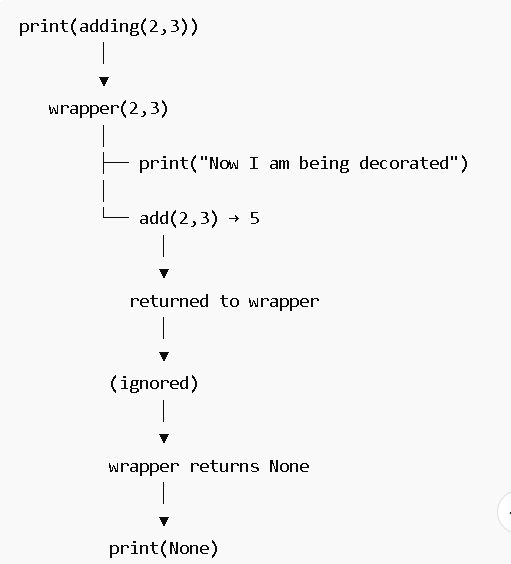

In [ ]:
def add(a,b):
    a + b

In [21]:
add(2, 3)

In [22]:
def add(a,b):
    return a +b

def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        return func(*args, **kwargs)
    return wrapper

adding = deco_func(add)
print(adding(2, 3))

Now I am being decorated
5


In [23]:
def add(a, b):
    return a + b

print("Original add id:", id(add))


def deco_func(func):
    print("Decorator received function id:", id(func))

    def wrapper(*args, **kwargs):
        print("Wrapper id:", id(wrapper))
        print("Function inside wrapper id:", id(func))
        print("Now I am being decorated")
        result = func(*args, **kwargs)
        return result

    print("Wrapper created with id:", id(wrapper))
    return wrapper


adding = deco_func(add)

print("adding id:", id(adding))

print(adding(2, 3))

Original add id: 2354247286624
Decorator received function id: 2354247286624
Wrapper created with id: 2354247273664
adding id: 2354247273664
Wrapper id: 2354247273664
Function inside wrapper id: 2354247286624
Now I am being decorated
5


In [26]:
def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        return func(*args, **kwargs)
    return wrapper

In [27]:
@deco_func
def add(a,b):
    return a+b

In [28]:
add(5, 6)

Now I am being decorated


11

# Map Function

In [61]:
def sq(a):
    return a**2

results = map(sq, [2, 3])

for result in results:
    print(result)

4
9


In [60]:
def multiply(a, b):
    return a * b

results = list(map(lambda x:multiply(*x), [(2, 3), (2,4)]))


print(results)

[6, 8]


# Filter Function

In [55]:
def find(x):
    if x > 2:
        return x
    
print(list(filter(find, [2, 2, 3])))

[3]


# Reduce Function

In [59]:
from functools import reduce
def multiply(a, b):
    return a * b

print(reduce(multiply, [1, 2, 3, 4]))

24


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 5000

data = pd.DataFrame({

    "temperature": np.random.normal(30,2,N),
    "pH": np.random.normal(7,0.5,N),
    "agitation_rpm": np.random.normal(500,80,N),
    "aeration_vvm": np.random.uniform(0.5,2,N),

    "fermentation_time": np.random.normal(24,4,N),

    "carbon_source_gL": np.random.uniform(20,60,N),
    "nitrogen_source_gL": np.random.uniform(5,20,N),

    "biomass_OD": np.random.uniform(20,80,N),

    "expression_rate": np.random.uniform(0.1,0.4,N),

    "centrifuge_speed": np.random.uniform(5000,15000,N),

    "lysis_efficiency": np.random.uniform(0.6,0.95,N),

    "precipitation_pH": np.random.uniform(4,7,N),

    "salt_concentration_M": np.random.uniform(0.5,2,N),

    "UF_pressure": np.random.uniform(10,30,N),

    "membrane_cutoff_kDa": np.random.choice([10,30,50],N),

    "chromatography_recovery": np.random.uniform(0.5,0.9,N)

})

# fermentation protein production

data["protein_expression"] = (
    data["biomass_OD"]
    * data["expression_rate"]
)

# released protein after lysis

data["released_protein"] = (
    data["protein_expression"]
    * data["lysis_efficiency"]
)

# precipitation efficiency

precip_eff = 0.7 + (data["precipitation_pH"]-5)*0.05

# UF efficiency

UF_eff = 0.8 - (data["UF_pressure"]-20)*0.005

# overall recovery

recovery = precip_eff * UF_eff * data["chromatography_recovery"]

# final protein

data["final_protein_recovered"] = (
    data["released_protein"]
    * recovery
)

data = data.drop(columns=["protein_expression","released_protein"])

print(data.head())

data.to_csv("fermentation_protein_dataset.csv", index=False)

# Namespace

**A namespace is a collection of names and the objects that they reference. Python will host a dictionary where the keys are the names that have been defined and the mapped values are the objects that they reference.**

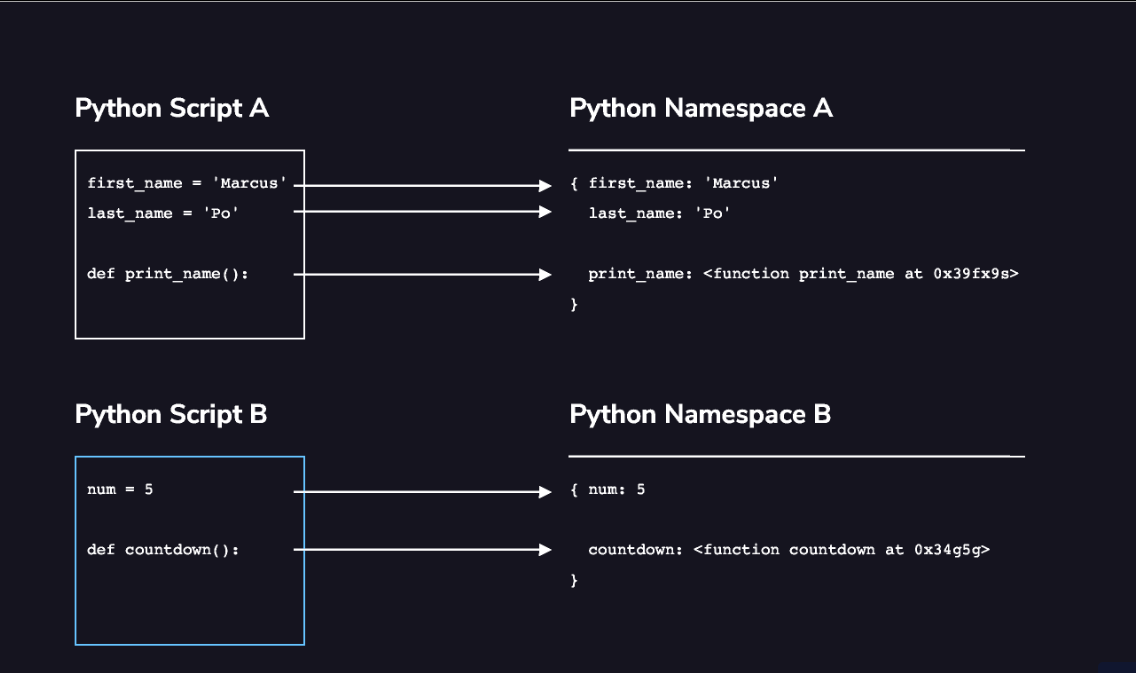

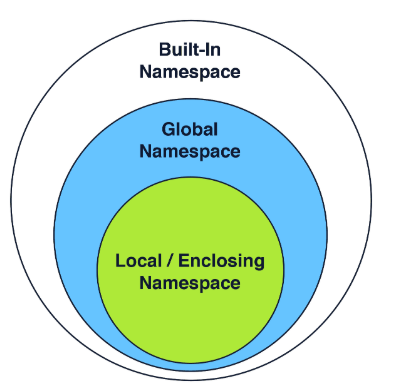

## builtins

In [17]:
print(dir(__builtins__)) 
# This allows us to access the builtins module that Python provides for us. 

['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'None', 'NotADirectoryError', 'NotImplemented', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning', 'StopAsyncIteration', 'S

Even Exceptions, Bool (True/False) and str(), zip(), enumerate() etc come under builin namespace.

In total there are 152 names that include exceptions, functions, types, special attributes, and other Python built-in objects.

Since Python provides the namespace, these objects are accessible without the need to import a separate module.

In [11]:
x = True
y = True

In [12]:
x is y

True

In [13]:
x = 2
y = 2

In [14]:
x is y

True

In [15]:
id(x)

140715543194072

In [16]:
id(y)

140715543194072

## globals()

In [19]:
import random

first_name = "Mrityunjay"
last_name = "Pathak"

def print_variables():
    random_number = random.randint(0, 9)
    print(first_name)
    print(last_name)
    print(random_number)

print_variables()

Mrityunjay
Pathak
6


In [20]:
print(globals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# Namespace', '# Namespace', 'print(dir(__builtin__))', 'x is y', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'print(dir(__builtins__)) \n# This allows us to access the builtins module that Python provides for us. ', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_number)', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_

The global namespace contains all of the ***non-nested objects*** of our program. This includes the variables first_name and last_name as well as the function print_variables. However, the random_number variable is not included in the namespace because it is nested inside of our function. Don’t worry we will learn about the namespace that random_number exists inside in the next exercise.

In [ ]:
def print_global():
  global_variable = "nested global"
  nested_variable = "nested value"


print(' \n -- Globals Namespace non-empty script -- \n')
# Write Checkpoint 4 here: 
print(globals())

 
 -- Globals Namespace non-empty script -- 

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# Namespace', '# Namespace', 'print(dir(__builtin__))', 'x is y', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'print(dir(__builtins__)) \n# This allows us to access the builtins module that Python provides for us. ', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_number)', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_

## locals()

In [23]:
global_variable = 'global'

def add(num1, num2):
  nested_value = 'Inside Function'   
  print(num1 + num2)

print(locals())

add(5, 10) 


{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# Namespace', '# Namespace', 'print(dir(__builtin__))', 'x is y', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'print(dir(__builtins__)) \n# This allows us to access the builtins module that Python provides for us. ', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_number)', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_

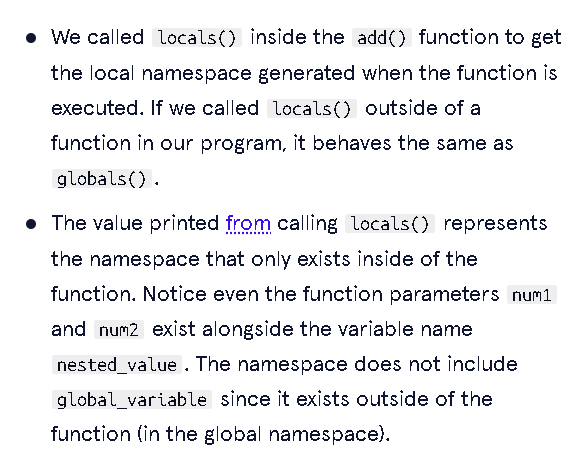

In [27]:
global_variable = 'global'



print(' -- Local and global Namespaces with empty script -- \n')
# Write Checkpoint 1 here:
print(locals())
print(globals())

# Write Checkpoint 2 here:
def divide(num1, num2):
  result = num1 / num2
  print(locals())

# Write Checkpoint 3 here:
def multiply(num1, num2):
  product = num1 * num2
  print(locals())



print(' \n -- Local Namespace for divide -- \n')
# Write Checkpoint 4 here:
divide(3, 4)

print(' \n -- Local Namespace for multiply -- \n')
# Write Checkpoint 5 here:
multiply(4, 50)

print(' \n -- Local Namespace final -- \n')
# Write Checkpoint 6 here:
print(locals())

 -- Local and global Namespaces with empty script -- 

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# Namespace', '# Namespace', 'print(dir(__builtin__))', 'x is y', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'x = True\ny = True', 'x is y', 'x = 2\ny = 2', 'x is y', 'id(x)', 'id(y)', 'print(dir(__builtins__)) \n# This allows us to access the builtins module that Python provides for us. ', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    print(first_name)\n    print(last_name)\n    print(random_number)', 'import random\n\nfirst_name = "Mrityunjay"\nlast_name = "Pathak"\n\ndef print_variables():\n    random_number = random.randint(0, 9)\n    pri

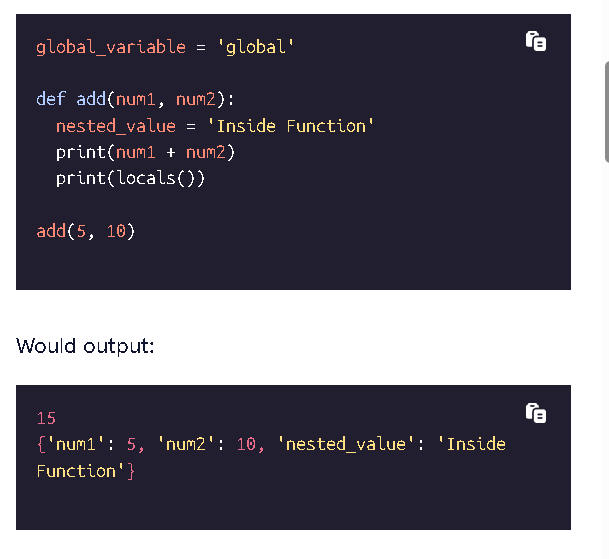

In [ ]:
global_variable = 'global'
 
def outer_function():
  outer_value = "outer"
 
  def inner_function():
    inner_value = "inner"

    def inner_nested_function():
      nested_value = 'nested'
    inner_nested_function()
    # Add locals() below
    print(locals())
  inner_function()
 
outer_function()

In [1]:
print(globals())

def simple_math_func():
  x = 10
  y = 2
  mult = x * y
  add = x + y

print(locals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', 'print(globals())\n\ndef simple_math_func():\n  x = 10\n  y = 2\n  mult = x * y\n  add = x + y\n\nprint(locals())'], '_oh': {}, '_dh': [WindowsPath('c:/Users/mriyu/OneDrive/Desktop/DS2026/Python_2026')], 'In': ['', 'print(globals())\n\ndef simple_math_func():\n  x = 10\n  y = 2\n  mult = x * y\n  add = x + y\n\nprint(locals())'], 'Out': {}, 'get_ipython': <bound method InteractiveShell.get_ipython of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x0000028D2DCB05F0>>, 'exit': <IPython.core.autocall.ZMQExitAutocall object at 0x0000028D2DF527E0>, 'quit': <IPython.core.autocall.ZMQExitAutocall object at 0x0000028D2DF527E0>, 'open': <function open at 0x0000028D2BD14180>, '_': '', '__': '', '___': '', '__vsc_ipynb_file__':

In the previous code block, even though locals() is called outside a function (and is thus usually equivalent to globals()), it is called after a new function is defined, thus the namespace will be different than the first globals() call.

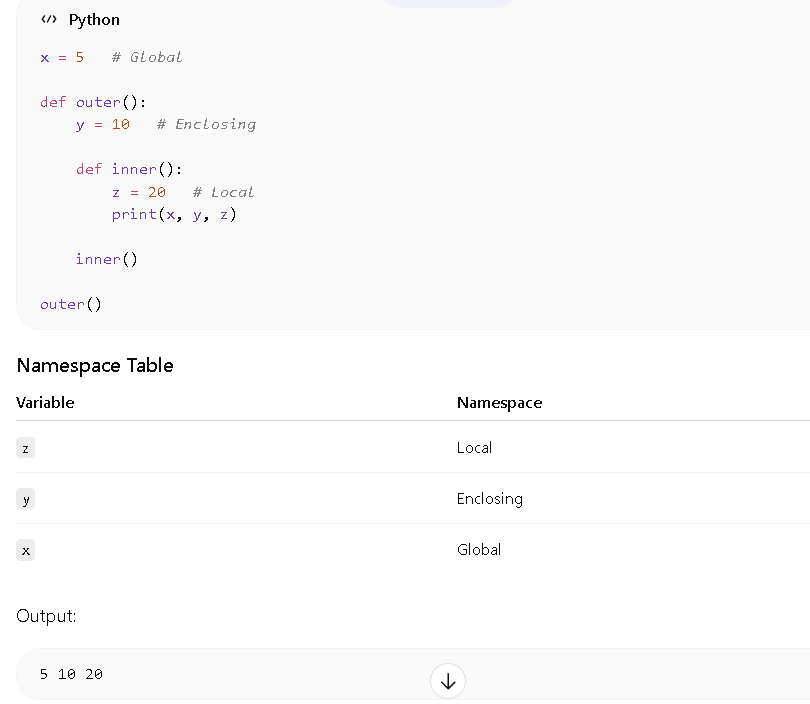

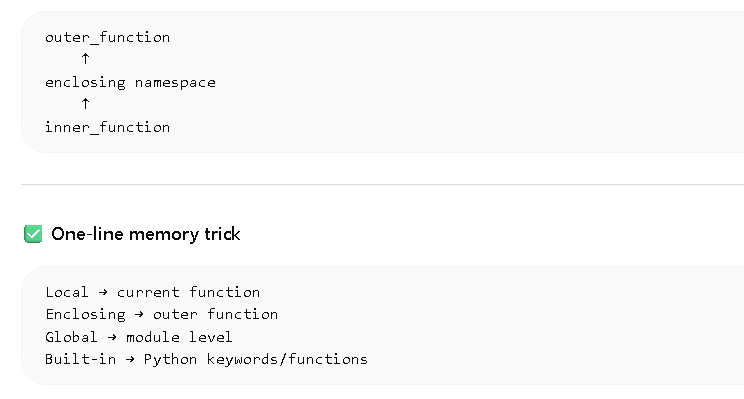